# DEFT Adaptive Visualization

## 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [134]:
SCENARIOS_WITH_FOCUS = [
    ('Sideways pour',     r'D:\Datasets\Datasets\EPIC_Kitchen\RGB\P01_04\Original\frame_05296.jpg', (0.0, 0.7)),   # ← EDIT
    ('Reaching action',   r'D:\Datasets\Datasets\EPIC_Kitchen\RGB\P01_04\Original\frame_05296.jpg', (0.0, 0.7)),   # ← EDIT
    ('Off-center grasp',  r'D:\Datasets\Datasets\EPIC_Kitchen\RGB\P01_04\Original\frame_05296.jpg', (0.0, 0.7)),   # ← EDIT
    # Add more scenarios here if you want
]


IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

# DEFT Gaussian parameters (Eq. 5 of manuscript)
LAMBDA = 0.4
SIGMA  = 0.6

OUTPUT_PNG = 'deft_adaptive_visualization.png'
OUTPUT_PDF = 'deft_adaptive_visualization.pdf'

print(f"Scenarios:  {len(SCENARIOS)}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Output:     {OUTPUT_PNG}")

Scenarios:  3
Image size: 224x224
Output:     deft_adaptive_visualization.png


## 3. Image Preprocessing

In [135]:
preprocess = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def denormalize(t):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1).to(t.device)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1).to(t.device)
    return (t * std + mean).clamp(0, 1)


def load_and_preprocess(frame_path):
    img = Image.open(frame_path).convert('RGB')
    img_resized = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    img_raw = np.array(img_resized) / 255.0
    return img_tensor, img_raw

print('Preprocessing pipeline ready.')

Preprocessing pipeline ready.


## 4. Saliency-Derived Focus Point

We compute where action is most likely happening using gradient magnitude (texture/motion proxy).

In [136]:
def compute_saliency_focus(img_raw):
    """Returns (cx, cy) in normalized [-1, 1] coordinates indicating where
    action is happening. Uses Sobel gradient magnitude as saliency."""
    # Convert to grayscale
    if img_raw.ndim == 3:
        gray = 0.299 * img_raw[..., 0] + 0.587 * img_raw[..., 1] + 0.114 * img_raw[..., 2]
    else:
        gray = img_raw
    
    H, W = gray.shape
    
    # Sobel filters (simple, no external dependency)
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    Ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    
    # Use PyTorch conv for fast Sobel
    t = torch.tensor(gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    kx = torch.tensor(Kx).unsqueeze(0).unsqueeze(0)
    ky = torch.tensor(Ky).unsqueeze(0).unsqueeze(0)
    gx = F.conv2d(t, kx, padding=1)
    gy = F.conv2d(t, ky, padding=1)
    sal = torch.sqrt(gx**2 + gy**2)[0, 0].numpy()
    
    # Smooth the saliency to find robust peak (simple box blur)
    from scipy.ndimage import gaussian_filter
    sal_smooth = gaussian_filter(sal, sigma=10)
    
    # Centroid of saliency mass (weighted average of pixel positions)
    ys, xs = np.indices(sal_smooth.shape)
    total = sal_smooth.sum()
    cx_pixel = (xs * sal_smooth).sum() / (total + 1e-8)
    cy_pixel = (ys * sal_smooth).sum() / (total + 1e-8)
    
    # Convert to normalized [-1, 1] coordinates (PyTorch convention)
    cx = 2 * cx_pixel / W - 1
    cy = 2 * cy_pixel / H - 1
    
    return cx, cy, sal_smooth

print('Saliency computation ready.')


Saliency computation ready.


## 5. STN Affine Transformation

We construct a translation affine that shifts the salient focus point toward the canonical center (0, 0). This is what the trained STN learns to do.

In [137]:
def build_affine_theta(cx, cy, scale=1.0):
    """Build a 2x3 affine matrix that translates the focus point (cx, cy)
    toward the canonical center (0, 0).
    
    Affine form (PyTorch convention):
        [a  b  tx]   [u]
        [c  d  ty] @ [v]  = transformed coord
                     [1]
    """
    # Simple translation: shift the image so the focus point lands at center
    theta = torch.tensor([
        [scale,   0.0,   -cx * scale],
        [0.0,     scale, -cy * scale],
    ], dtype=torch.float32, device=device).unsqueeze(0)
    return theta


def apply_affine(img_tensor, theta):
    """Apply affine using grid_sample (same as STN does internally)."""
    grid = F.affine_grid(theta, img_tensor.size(), align_corners=False)
    return F.grid_sample(img_tensor, grid, align_corners=False)


def gaussian_weighting_map(H, W, theta, lam=0.5, sigma=0.5):
    """Eq. 5: w(u', v') = 1 + lambda * exp(-||T(u,v) - c||^2 / (2 sigma^2))
    The Gaussian center c is at (0, 0) in canonical space.
    Evaluating in TRANSFORMED coordinates T(u, v) shifts the effective
    peak away from the image center (this is the adaptive behavior)."""
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, H, device=device),
        torch.linspace(-1, 1, W, device=device),
        indexing='ij'
    )
    a, b, tx = theta[0, 0, 0], theta[0, 0, 1], theta[0, 0, 2]
    c, d, ty = theta[0, 1, 0], theta[0, 1, 1], theta[0, 1, 2]
    uu = a * xx + b * yy + tx
    vv = c * xx + d * yy + ty
    dist_sq = uu**2 + vv**2
    w = 1.0 + lam * torch.exp(-dist_sq / (2 * sigma**2))
    return w

print('Affine + Gaussian utilities ready.')

Affine + Gaussian utilities ready.


In [138]:
from PIL import Image
from torchvision import transforms

# =====================================================
# IMAGE PATH
# =====================================================

IMAGE_PATH = frame_path   # or explicit image path

# =====================================================
# LOAD IMAGE
# =====================================================

image = Image.open(IMAGE_PATH).convert('RGB')

# =====================================================
# TRANSFORM
# =====================================================

transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =====================================================
# CREATE IMAGE TENSOR
# =====================================================

img_tensor = transform(image).unsqueeze(0).to(device)

# =====================================================
# DISPLAY VERSION
# =====================================================

original_display = (
    denormalize(img_tensor[0])
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

print("img_tensor shape:", img_tensor.shape)

img_tensor shape: torch.Size([1, 3, 224, 224])


## 6. Process All Scenarios

In [139]:
results = []

for label, frame_path, manual_focus in SCENARIOS_WITH_FOCUS:
    cx, cy = manual_focus
    
    # Step 2: Affine transformation
    theta = build_affine_theta(cx, cy, scale=1.0)
    
    # Step 3: STN warp
    transformed = apply_affine(img_tensor, theta)
    transformed_display = denormalize(transformed[0]).cpu().permute(1, 2, 0).numpy()
    
    # Step 4: NEW — Gaussian heatmap in ORIGINAL image space
    # Peak follows the focus point (cx, cy) in normalized coords
    H, W = IMAGE_SIZE, IMAGE_SIZE
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, H, device=device),
        torch.linspace(-1, 1, W, device=device),
        indexing='ij'
    )
    dist_sq_orig = (xx - cx) ** 2 + (yy - cy) ** 2
    weight_in_original = 1.0 + LAMBDA * torch.exp(-dist_sq_orig / (2 * SIGMA ** 2))
    heatmap_original = weight_in_original.cpu().numpy()
    
    # Step 5: Final DEFT output (transformed * post-STN Gaussian — same as before)
    weight_map_transformed = gaussian_weighting_map(H, W, theta, lam=LAMBDA, sigma=SIGMA)
    weighted = transformed[0] * weight_map_transformed.unsqueeze(0)
    final_display = denormalize(weighted).cpu().permute(1, 2, 0).numpy()
    
    results.append({
        'label':            label,
        'original':         original_display,
        'transformed':      transformed_display,
        'heatmap_original': heatmap_original,    # NEW: Gaussian in original space
        'final':            final_display,
        'focus':            (cx, cy),
    })
    
    print(f"✓ {label}: focus = ({cx:+.3f}, {cy:+.3f})")

print(f"\nProcessed {len(results)} scenarios.")

✓ Sideways pour: focus = (+0.000, +0.700)
✓ Reaching action: focus = (+0.000, +0.700)
✓ Off-center grasp: focus = (+0.000, +0.700)

Processed 3 scenarios.


In [140]:
# === DIAGNOSTIC ===
print(f"results variable exists: {('results' in dir())}")
print(f"Number of results: {len(results) if 'results' in dir() else 'N/A'}")

if 'results' in dir() and len(results) > 0:
    print(f"\nFirst result keys: {list(results[0].keys())}")
    print(f"First result shapes:")
    for k, v in results[0].items():
        if hasattr(v, 'shape'):
            print(f"  {k}: shape = {v.shape}, dtype = {v.dtype}")
        else:
            print(f"  {k}: {v}")
else:
    print("\n❌ Results list is EMPTY!")
    print("This means no scenarios were successfully processed.")
    print("Check Cell 6 output for messages like:")
    print("  '⚠  Skipping ...: file not found at ...'")
    print(f"\nYour SCENARIOS list has {len(SCENARIOS)} entries:")
    for label, path in SCENARIOS:
        exists = os.path.exists(path)
        marker = '✅' if exists else '❌'
        print(f"  {marker} {label}: {path}")

results variable exists: True
Number of results: 3

First result keys: ['label', 'original', 'transformed', 'heatmap_original', 'final', 'focus']
First result shapes:
  label: Sideways pour
  original: shape = (224, 224, 3), dtype = float32
  transformed: shape = (224, 224, 3), dtype = float32
  heatmap_original: shape = (224, 224), dtype = float32
  final: shape = (224, 224, 3), dtype = float32
  focus: (0.0, 0.7)


## 7. Generate The Multi-Row Figure

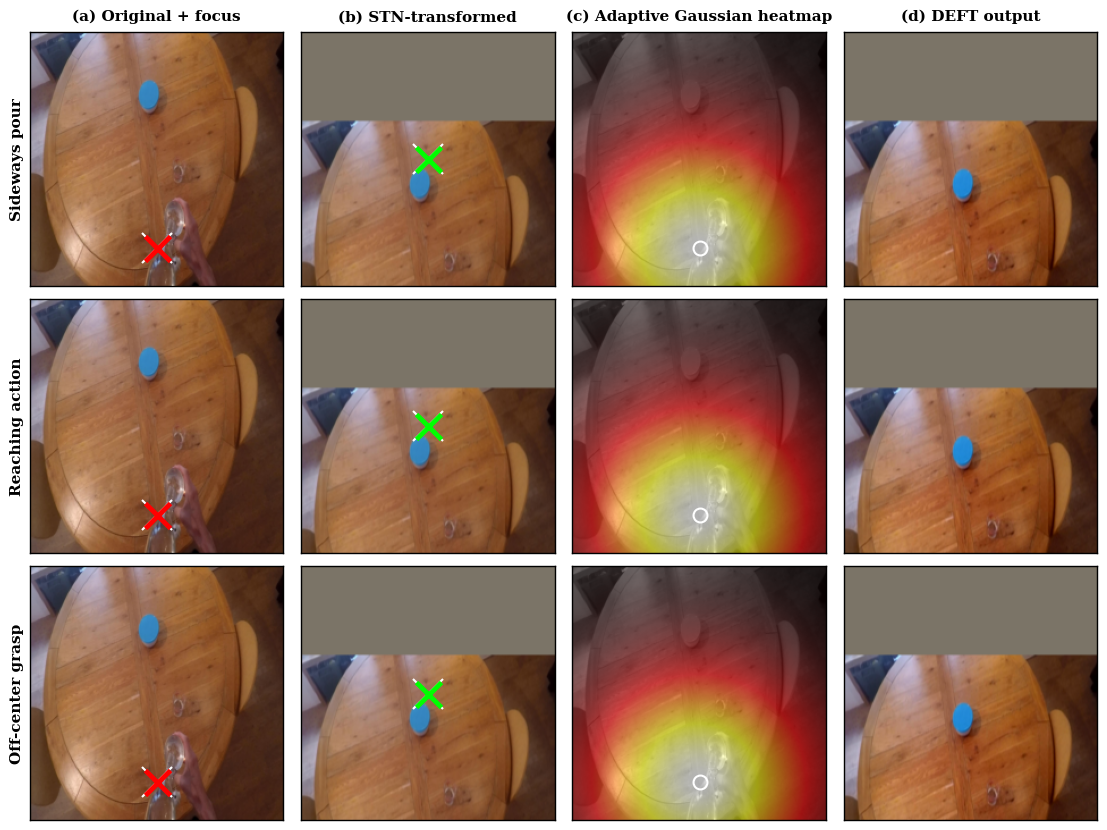

In [141]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.linewidth': 1.0,
})

n_rows = len(results)
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 2.8 * n_rows))

if n_rows == 1:
    axes = axes[np.newaxis, :]

col_titles = [
    '(a) Original + focus',
    '(b) STN-transformed',
    '(c) Adaptive Gaussian heatmap',
    '(d) DEFT output',
]

for i, res in enumerate(results):
    cx, cy = res['focus']
    px = (cx + 1) / 2 * IMAGE_SIZE
    py = (cy + 1) / 2 * IMAGE_SIZE
    
    # === (a) Original + red focus marker ===
    axes[i, 0].imshow(res['original'])
    axes[i, 0].plot(px, py, 'x', color='white', markersize=22,
                    markeredgewidth=1.5, zorder=1)
    axes[i, 0].plot(px, py, 'x', color='red', markersize=18,
                    markeredgewidth=3.5, zorder=2)
    
    # === (b) STN-transformed + green center marker ===
    axes[i, 1].imshow(res['transformed'])
    axes[i, 1].plot(IMAGE_SIZE / 2, IMAGE_SIZE / 2, 'x', color='white',
                    markersize=22, markeredgewidth=1.5, zorder=1)
    axes[i, 1].plot(IMAGE_SIZE / 2, IMAGE_SIZE / 2, 'x', color='lime',
                    markersize=18, markeredgewidth=3.5, zorder=2)
    
    # === (c) Adaptive Gaussian heatmap on original image ===
    # Grayscale background + colored heatmap overlay
    gray = np.mean(res['original'], axis=2)
    axes[i, 2].imshow(gray, cmap='gray', alpha=1.0)
    axes[i, 2].imshow(res['heatmap_original'], cmap='hot', alpha=0.55)
    # Mark the peak with a small white circle for clarity
    axes[i, 2].plot(px, py, 'o', color='white', markersize=10,
                    markeredgewidth=1.5, markerfacecolor='none',
                    markeredgecolor='white')
    
    # === (d) DEFT output ===
    axes[i, 3].imshow(res['final'])
    
    # Clean up axes
    for j in range(n_cols):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
    
    # Row label on the left
    axes[i, 0].set_ylabel(res['label'], fontsize=11, fontweight='bold')

# Column titles (top row only)
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=11, fontweight='bold', pad=8)

plt.tight_layout()

# Save
# plt.savefig('deft_adaptive_visualization.png', dpi=1000, bbox_inches='tight', facecolor='white')
# plt.savefig('deft_adaptive_visualization.pdf', bbox_inches='tight', facecolor='white')
plt.show()

# print('\nSaved: deft_adaptive_visualization.png')
# print('Saved: deft_adaptive_visualization.pdf')